# Unsupervised Learning - K-Means untuk Segmentasi Kondisi Lahan

Notebook detail ini menjelaskan proses unsupervised learning menggunakan **K-Means Clustering** untuk mengelompokkan kondisi lahan. Setiap code cell dilengkapi penjelasan teknis, alasan penggunaan, dan interpretasi hasil agar anggota kelompok memahami alur clustering.

Peran notebook ini dalam project:

- Input: `N`, `P`, `K`, `temperature`, `humidity`, `ph`, dan `rainfall`.
- Output: cluster atau tipe kondisi lahan.
- Tujuan: menemukan pola kondisi lahan tanpa menggunakan label tanaman saat training.


## 1. Import Library

**Tujuan cell:** memanggil library yang dibutuhkan untuk membaca data, preprocessing, clustering, evaluasi cluster, visualisasi, dan penyimpanan model.

**Penjelasan teknis:**

- `pandas` digunakan untuk mengolah dataset.
- `numpy` digunakan untuk perhitungan numerik, termasuk deteksi titik elbow.
- `matplotlib` dan `seaborn` digunakan untuk grafik.
- `StandardScaler` digunakan untuk standardisasi fitur.
- `KMeans` digunakan untuk clustering.
- `silhouette_score`, `calinski_harabasz_score`, dan `davies_bouldin_score` digunakan untuk evaluasi cluster.
- `PCA` digunakan untuk visualisasi cluster dalam 2 dimensi.
- `joblib` digunakan untuk menyimpan model.

**Alasan:** K-Means membutuhkan preprocessing dan evaluasi yang berbeda dari supervised learning, sehingga library khusus clustering dan scaling diperlukan.


In [16]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv"


### Interpretasi hasil cell 1

Cell ini tidak menghasilkan output karena hanya memuat library dan konfigurasi awal. Jika tidak ada error, berarti seluruh library yang dibutuhkan untuk clustering tersedia di Kaggle.


## 2. Memuat Dataset

**Tujuan cell:** membaca dataset dari path Kaggle dan menampilkan ukuran serta contoh data awal.

**Penjelasan teknis:**

- `os.path.exists(DATA_PATH)` memastikan file dataset tersedia.
- `pd.read_csv()` membaca file CSV menjadi DataFrame.
- `df.shape` menampilkan jumlah baris dan kolom.
- `df.head()` menampilkan lima baris pertama.

**Alasan:** sebelum clustering dilakukan, kita harus memastikan dataset sudah terbaca dan struktur kolomnya sesuai.


In [17]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Ukuran dataset:", df.shape)
df.head()


Ukuran dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Interpretasi hasil cell 2

Output menunjukkan dataset berhasil dibaca dengan ukuran **2200 baris dan 8 kolom**. Ini berarti file CSV sudah ditemukan pada path Kaggle dan siap digunakan untuk analisis clustering.


## 3. Cek Struktur Data

**Tujuan cell:** mengecek kualitas dasar dataset sebelum clustering.

**Penjelasan teknis:**

- Daftar kolom dicek untuk memastikan fitur yang dibutuhkan tersedia.
- Missing value dicek karena K-Means tidak dapat bekerja baik jika ada nilai kosong.
- Duplikasi dicek agar data berulang tidak memengaruhi pusat cluster.
- Statistik deskriptif digunakan untuk melihat rentang dan sebaran fitur.

**Alasan:** K-Means sensitif terhadap data numerik dan jarak antar data, sehingga kualitas data awal harus dipastikan terlebih dahulu.


In [18]:
print("Kolom dataset:")
print(df.columns.tolist())

print("\nMissing value:")
print(df.isna().sum())

print("\nJumlah duplikasi:", df.duplicated().sum())

df.describe().T


Kolom dataset:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Missing value:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Jumlah duplikasi: 0


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### Interpretasi hasil cell 3

Output menunjukkan tidak ada missing value dan tidak ada duplikasi. Ringkasan statistik memperlihatkan bahwa setiap fitur memiliki rentang nilai berbeda, misalnya `rainfall` jauh lebih besar daripada `ph`. Karena itu, standardisasi diperlukan sebelum K-Means.


## 4. Menentukan Fitur Clustering

**Tujuan cell:** memilih fitur yang akan digunakan untuk clustering kondisi lahan.

**Penjelasan teknis:**

- `feature_columns` berisi tujuh fitur tanah dan lingkungan.
- `label_column` disimpan hanya untuk interpretasi setelah clustering.
- `X` berisi data fitur yang akan dipakai K-Means.

**Alasan:** K-Means adalah unsupervised learning, sehingga kolom `label` tidak boleh digunakan saat pembentukan cluster. Jika label digunakan, clustering tidak lagi murni berdasarkan pola kondisi lahan.


In [19]:
feature_columns = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
label_column = "label"

X = df[feature_columns]

print("Fitur clustering:", feature_columns)


Fitur clustering: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


### Interpretasi hasil cell 4

Output menunjukkan fitur clustering yang digunakan adalah `N`, `P`, `K`, `temperature`, `humidity`, `ph`, dan `rainfall`. Kolom `label` tidak digunakan untuk pembentukan cluster, sehingga clustering benar-benar berdasarkan kondisi tanah dan lingkungan.


## 5. Standardisasi Fitur

**Tujuan cell:** mengubah seluruh fitur numerik agar berada pada skala yang sebanding.

**Penjelasan teknis:**

- `StandardScaler()` mengubah setiap fitur menjadi rata-rata 0 dan standar deviasi 1.
- `fit_transform(X)` menghitung parameter scaling dan langsung menerapkannya ke data.
- Hasil scaling disimpan sebagai `X_scaled`.

**Alasan:** K-Means menghitung jarak. Jika fitur tidak distandardisasi, fitur dengan angka besar seperti `rainfall` atau `K` bisa terlalu mendominasi clustering.


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)
scaled_df.head()


,N,P,K,temperature,humidity,ph,rainfall
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373


### Interpretasi hasil cell 5

Output menampilkan data setelah standardisasi. Nilai tidak lagi berada pada skala asli, tetapi sudah diubah agar setiap fitur memiliki skala sebanding. Data `X_scaled` inilah yang dipakai untuk K-Means.


## 6. Menentukan Jumlah Cluster dengan Elbow Method

**Tujuan cell:** mencoba beberapa nilai `k` dan menentukan jumlah cluster menggunakan Elbow Method.

**Penjelasan teknis:**

- `k_values = range(2, 13)` mencoba jumlah cluster dari 2 sampai 12.
- Untuk setiap `k`, K-Means dilatih dan nilai inertia dihitung.
- `inertia` mengukur total jarak kuadrat data terhadap pusat cluster masing-masing.
- Silhouette score juga dihitung sebagai pembanding kualitas cluster.
- `elbow_distance` dihitung sebagai jarak titik inertia terhadap garis lurus dari titik awal ke titik akhir.
- `elbow_k` dipilih dari titik dengan jarak terbesar.

**Alasan:** Elbow Method digunakan karena materi dosen menekankan metode ini untuk menentukan jumlah cluster.


In [21]:
k_values = range(2, 13)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    cluster_temp = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_temp))

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
})

points = elbow_df[["k", "inertia"]].to_numpy(dtype=float)
first_point = points[0]
last_point = points[-1]
line_vector = last_point - first_point
line_unit = line_vector / np.linalg.norm(line_vector)

projection = first_point + np.outer(np.dot(points - first_point, line_unit), line_unit)
elbow_df["elbow_distance"] = np.linalg.norm(points - projection, axis=1)

elbow_k = int(elbow_df.loc[elbow_df["elbow_distance"].idxmax(), "k"])

elbow_df


,k,inertia,silhouette_score,elbow_distance
0,2,11738.011336,0.416846,0.000000e+00
1,3,9489.462043,0.251864,1.766025e+00
2,4,8105.863755,0.255269,2.468041e+00
3,5,6856.211728,0.292475,3.005285e+00
4,6,6045.092878,0.304446,3.003073e+00
5,7,5248.625716,0.333252,2.982837e+00
6,8,4842.083075,0.326573,2.482941e+00
7,9,4472.450608,0.332270,1.937641e+00
8,10,4110.154305,0.348772,1.383316e+00
9,11,3845.087840,0.347069,7.093844e-01


### Interpretasi hasil cell 6

Tabel menunjukkan nilai inertia, silhouette score, dan elbow distance untuk setiap `k`. Nilai elbow distance terbesar berada pada **k = 5**, sehingga jumlah cluster yang dipilih berdasarkan Elbow Method adalah 5. Silhouette tertinggi memang ada pada k = 2, tetapi notebook ini mengikuti Elbow Method sebagai acuan utama sesuai materi.


## 7. Visualisasi Elbow Method

**Tujuan cell:** menampilkan grafik Elbow Method dan Silhouette Score.

**Penjelasan teknis:**

- Grafik kiri menampilkan nilai inertia untuk setiap `k`.
- Garis merah menunjukkan `elbow_k` yang dipilih.
- Grafik kanan menampilkan silhouette score sebagai pembanding.

**Alasan:** visualisasi membantu menjelaskan mengapa jumlah cluster tertentu dipilih. Grafik ini penting untuk laporan dan presentasi.


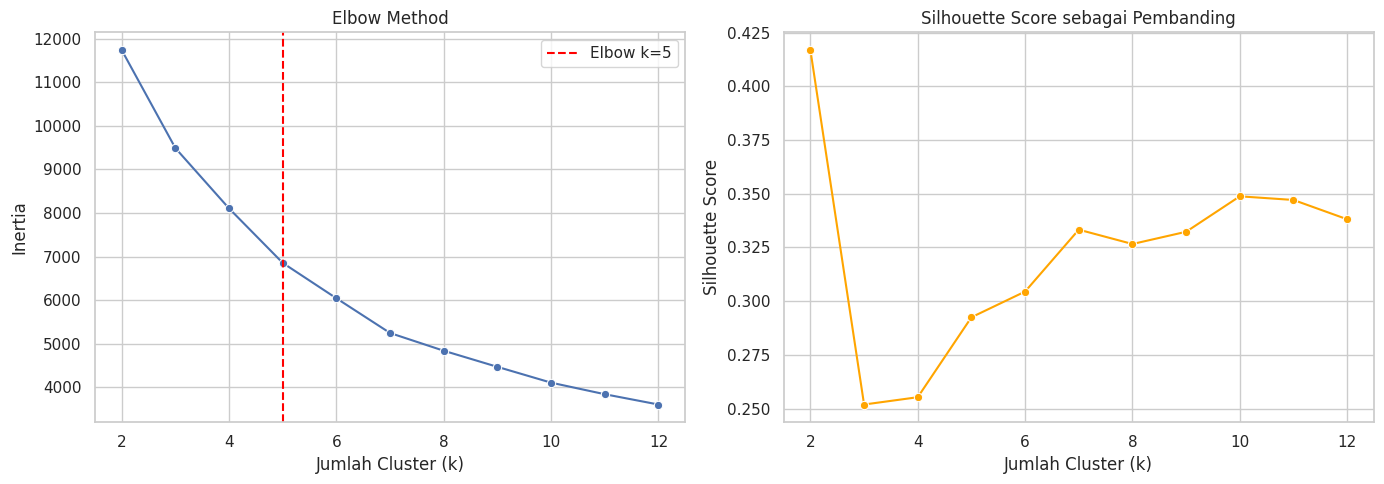

Jumlah cluster berdasarkan Elbow Method: 5


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=elbow_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].axvline(elbow_k, color="red", linestyle="--", label=f"Elbow k={elbow_k}")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

sns.lineplot(data=elbow_df, x="k", y="silhouette_score", marker="o", ax=axes[1], color="orange")
axes[1].set_title("Silhouette Score sebagai Pembanding")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

print(f"Jumlah cluster berdasarkan Elbow Method: {elbow_k}")


### Interpretasi hasil cell 7

Grafik Elbow Method menunjukkan titik siku pada **k = 5**. Grafik silhouette digunakan sebagai pembanding, bukan sebagai penentu utama. Output teks juga menegaskan bahwa jumlah cluster berdasarkan Elbow Method adalah 5.


## 8. Melatih K-Means Final

**Tujuan cell:** melatih model K-Means final dengan jumlah cluster hasil Elbow Method.

**Penjelasan teknis:**

- `K_FINAL = elbow_k` berarti jumlah cluster mengikuti hasil Elbow Method.
- `KMeans(n_clusters=K_FINAL)` membuat model K-Means final.
- `fit_predict(X_scaled)` melatih model dan menghasilkan label cluster untuk setiap data.
- Label cluster disimpan ke kolom baru `cluster`.

**Alasan:** setelah jumlah cluster ditentukan, model final perlu dilatih agar setiap data memiliki kelompok kondisi lahan.


In [23]:
K_FINAL = elbow_k

kmeans_model = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=50)
clusters = kmeans_model.fit_predict(X_scaled)

clustered_df = df.copy()
clustered_df["cluster"] = clusters

print("Jumlah cluster final:", K_FINAL)
print("Jumlah data per cluster:")
print(clustered_df["cluster"].value_counts().sort_index())


Jumlah cluster final: 5
Jumlah data per cluster:
cluster
0    627
1    558
2    580
3    200
4    235
Name: count, dtype: int64


### Interpretasi hasil cell 8

K-Means final dilatih dengan **5 cluster**. Jumlah data per cluster adalah 627, 558, 580, 200, dan 235. Artinya, terdapat tiga cluster besar dan dua cluster yang lebih spesifik.


## 9. Evaluasi Kualitas Cluster

**Tujuan cell:** menghitung metrik evaluasi untuk kualitas cluster.

**Penjelasan teknis:**

- `silhouette_score` mengukur seberapa mirip data dengan cluster-nya sendiri dibanding cluster lain.
- `calinski_harabasz_score` mengukur rasio pemisahan antar-cluster dan kepadatan dalam cluster.
- `davies_bouldin_score` mengukur kemiripan antar-cluster; nilai lebih rendah lebih baik.

**Alasan:** karena K-Means tidak memiliki label benar-salah, evaluasinya menggunakan metrik internal clustering.


In [24]:
silhouette = silhouette_score(X_scaled, clusters)
calinski = calinski_harabasz_score(X_scaled, clusters)
davies = davies_bouldin_score(X_scaled, clusters)

print(f"Silhouette Score       : {silhouette:.4f}")
print(f"Calinski-Harabasz Score: {calinski:.4f}")
print(f"Davies-Bouldin Score   : {davies:.4f}")


Silhouette Score       : 0.2925
Calinski-Harabasz Score: 683.8184
Davies-Bouldin Score   : 1.2803


### Interpretasi hasil cell 9

Silhouette Score sebesar **0.2925** menunjukkan kualitas pemisahan cluster berada pada tingkat sedang. Calinski-Harabasz Score sebesar **683.8184** menunjukkan adanya struktur cluster yang dapat dibedakan. Davies-Bouldin Score sebesar **1.2803** digunakan sebagai ukuran tambahan, dengan nilai lebih rendah menunjukkan cluster yang lebih baik.


## 10. Profil Rata-Rata Tiap Cluster

**Tujuan cell:** melihat karakteristik rata-rata setiap cluster dalam skala asli.

**Penjelasan teknis:**

- `groupby("cluster")` mengelompokkan data berdasarkan cluster.
- `mean()` menghitung rata-rata fitur untuk setiap cluster.
- `round(2)` membulatkan angka agar tabel mudah dibaca.

**Alasan:** profil rata-rata cluster menjadi dasar utama untuk memberi label kondisi lahan, seperti lahan basah, lahan kering, atau lahan dengan mineral tinggi.


In [25]:
cluster_profile = clustered_df.groupby("cluster")[feature_columns].mean().round(2)
cluster_profile


,N,P,K,temperature,humidity,ph,rainfall
cluster,,,,,,,
0,25.74,52.05,23.15,29.57,65.56,6.63,74.13
1,99.44,41.51,37.51,25.64,78.66,6.44,75.78
2,49.04,32.86,34.09,24.54,85.11,6.52,168.07
3,21.99,133.38,200.00,23.24,87.10,5.98,91.13
4,28.70,67.51,45.56,19.70,23.33,6.42,98.50


### Interpretasi hasil cell 10

Tabel profil cluster menunjukkan karakter rata-rata setiap cluster. Contohnya, cluster 2 memiliki `rainfall` tertinggi sehingga cocok diberi label lahan basah, sedangkan cluster 4 memiliki `humidity` terendah sehingga cocok diberi label lahan kering-sejuk.


## 11. Memberi Label Tipe Kondisi Lahan

**Tujuan cell:** memberi nama yang mudah dipahami pada setiap cluster berdasarkan profil rata-rata fitur.

**Penjelasan teknis:**

- Fungsi `add_label()` menyimpan label cluster dan alasan berbasis data.
- Cluster dengan `rainfall` tertinggi diberi label lahan basah.
- Cluster dengan `humidity` terendah diberi label lahan kering-sejuk.
- Cluster dengan `K` tertinggi diberi label lahan mineral P-K tinggi.
- Cluster dengan `N` tertinggi diberi label lahan nitrogen tinggi dan lembap.
- Cluster tersisa diberi label berdasarkan karakter umum suhu, curah hujan, dan kelembapan.

**Alasan:** angka cluster seperti 0, 1, 2 tidak mudah dipahami. Label kondisi lahan membuat hasil clustering lebih mudah dijelaskan dalam laporan Smart Farming.


In [26]:
label_info = []
used_clusters = []


def add_label(cluster_id, label, reason_features):
    reason = "; ".join([
        f"{feature}={cluster_profile.loc[cluster_id, feature]:.2f}"
        for feature in reason_features
    ])
    label_info.append({
        "cluster": int(cluster_id),
        "label_tipe_lahan": label,
        "alasan_berdasarkan_data": reason,
    })
    used_clusters.append(cluster_id)

# 1. Cluster dengan curah hujan tertinggi.
basah = cluster_profile["rainfall"].idxmax()
add_label(basah, "Lahan Basah / Curah Hujan Tinggi", ["rainfall", "humidity", "N"])

# 2. Cluster tersisa dengan kelembapan terendah.
sisa = cluster_profile.drop(index=used_clusters)
kering = sisa["humidity"].idxmin()
add_label(kering, "Lahan Kering-Sejuk / Kelembapan Rendah", ["humidity", "temperature", "rainfall"])

# 3. Cluster tersisa dengan Kalium tertinggi.
sisa = cluster_profile.drop(index=used_clusters)
mineral = sisa["K"].idxmax()
add_label(mineral, "Lahan Lembap / Mineral P-K Tinggi", ["K", "P", "humidity"])

# 4. Cluster tersisa dengan Nitrogen tertinggi.
sisa = cluster_profile.drop(index=used_clusters)
subur = sisa["N"].idxmax()
add_label(subur, "Lahan Subur / Nitrogen Tinggi dan Lembap", ["N", "humidity", "rainfall"])

# 5. Cluster terakhir.
for cluster_id in cluster_profile.index:
    if cluster_id not in used_clusters:
        add_label(cluster_id, "Lahan Hangat / Curah Hujan Rendah-Sedang", ["temperature", "rainfall", "humidity"])

cluster_label_df = pd.DataFrame(label_info).sort_values("cluster")
cluster_label_map = dict(zip(cluster_label_df["cluster"], cluster_label_df["label_tipe_lahan"]))

clustered_df["label_tipe_lahan"] = clustered_df["cluster"].map(cluster_label_map)
cluster_label_df


,cluster,label_tipe_lahan,alasan_berdasarkan_data
4,0,Lahan Hangat / Curah Hujan Rendah-Sedang,temperature=29.57; rainfall=74.13; humidity=65.56
3,1,Lahan Subur / Nitrogen Tinggi dan Lembap,N=99.44; humidity=78.66; rainfall=75.78
0,2,Lahan Basah / Curah Hujan Tinggi,rainfall=168.07; humidity=85.11; N=49.04
2,3,Lahan Lembap / Mineral P-K Tinggi,K=200.00; P=133.38; humidity=87.10
1,4,Lahan Kering-Sejuk / Kelembapan Rendah,humidity=23.33; temperature=19.70; rainfall=98.50


### Interpretasi hasil cell 11

Output menampilkan label tipe kondisi lahan dan alasan berbasis data. Setiap label memiliki dasar angka, misalnya `rainfall=168.07` untuk lahan basah atau `K=200.00` dan `P=133.38` untuk lahan mineral P-K tinggi. Ini membuat penamaan cluster dapat dipertanggungjawabkan.


## 12. Menggabungkan Profil Cluster dan Label Lahan

**Tujuan cell:** membuat tabel ringkasan final yang menggabungkan jumlah data, profil fitur, label lahan, dan alasan label.

**Penjelasan teknis:**

- `cluster_profile.copy()` menyalin profil rata-rata cluster.
- `value_counts()` menghitung jumlah data per cluster.
- `merge()` menggabungkan profil cluster dengan tabel label lahan.

**Alasan:** tabel ini adalah output utama K-Means yang paling mudah dipindahkan ke laporan.


In [27]:
cluster_summary = cluster_profile.copy()
cluster_summary.insert(0, "jumlah_data", clustered_df["cluster"].value_counts().sort_index())
cluster_summary = cluster_summary.reset_index()
cluster_summary = cluster_summary.merge(cluster_label_df, on="cluster", how="left")

cluster_summary


,cluster,jumlah_data,N,P,K,temperature,humidity,ph,rainfall,label_tipe_lahan,alasan_berdasarkan_data
0,0,627,25.74,52.05,23.15,29.57,65.56,6.63,74.13,Lahan Hangat / Curah Hujan Rendah-Sedang,temperature=29.57; rainfall=74.13; humidity=65.56
1,1,558,99.44,41.51,37.51,25.64,78.66,6.44,75.78,Lahan Subur / Nitrogen Tinggi dan Lembap,N=99.44; humidity=78.66; rainfall=75.78
2,2,580,49.04,32.86,34.09,24.54,85.11,6.52,168.07,Lahan Basah / Curah Hujan Tinggi,rainfall=168.07; humidity=85.11; N=49.04
3,3,200,21.99,133.38,200.00,23.24,87.10,5.98,91.13,Lahan Lembap / Mineral P-K Tinggi,K=200.00; P=133.38; humidity=87.10
4,4,235,28.70,67.51,45.56,19.70,23.33,6.42,98.50,Lahan Kering-Sejuk / Kelembapan Rendah,humidity=23.33; temperature=19.70; rainfall=98.50


### Interpretasi hasil cell 12

Tabel ini adalah ringkasan utama hasil K-Means. Setiap baris menunjukkan cluster, jumlah data, rata-rata fitur, label tipe lahan, dan alasan label. Tabel ini cocok dimasukkan ke bagian Results laporan.


## 13. Komposisi Tanaman pada Setiap Cluster

**Tujuan cell:** melihat jenis tanaman apa saja yang muncul pada setiap tipe kondisi lahan.

**Penjelasan teknis:**

- `pd.crosstab()` membuat tabel silang antara label tipe lahan dan label tanaman.
- Baris menunjukkan tipe kondisi lahan.
- Kolom menunjukkan jenis tanaman.

**Alasan:** label tanaman tidak dipakai untuk training K-Means, tetapi boleh digunakan setelah clustering untuk interpretasi. Ini membantu memahami tanaman apa yang dominan pada tiap tipe lahan.


In [28]:
cluster_crop_counts = pd.crosstab(clustered_df["label_tipe_lahan"], clustered_df[label_column])
cluster_crop_counts


label,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
label_tipe_lahan,,,,,,,,,,,,,,,,,,,,,
Lahan Basah / Curah Hujan Tinggi,0,0,0,0,100,47,0,0,99,0,...,0,0,0,0,73,48,13,100,100,0
Lahan Hangat / Curah Hujan Rendah-Sedang,0,0,100,0,0,0,0,0,0,0,...,100,100,100,0,27,45,59,0,0,0
Lahan Kering-Sejuk / Kelembapan Rendah,0,0,0,100,0,0,0,0,0,100,...,0,0,0,0,0,0,28,0,0,0
Lahan Lembap / Mineral P-K Tinggi,100,0,0,0,0,0,0,100,0,0,...,0,0,0,0,0,0,0,0,0,0
Lahan Subur / Nitrogen Tinggi dan Lembap,0,100,0,0,0,53,100,0,1,0,...,0,0,0,100,0,7,0,0,0,100


### Interpretasi hasil cell 13

Tabel silang menunjukkan komposisi tanaman pada setiap tipe kondisi lahan. Informasi ini hanya digunakan untuk interpretasi setelah clustering. Misalnya, tipe lahan tertentu bisa didominasi beberapa tanaman, tetapi itu bukan berarti K-Means melakukan prediksi tanaman.


## 14. Visualisasi Cluster dengan PCA

**Tujuan cell:** memvisualisasikan hasil cluster dalam grafik 2 dimensi.

**Penjelasan teknis:**

- PCA mengubah 7 fitur menjadi 2 komponen utama, yaitu PC1 dan PC2.
- Scatter plot menampilkan setiap data sebagai titik.
- Warna titik menunjukkan label tipe kondisi lahan.

**Alasan:** data asli memiliki 7 dimensi sehingga sulit divisualisasikan langsung. PCA membantu menampilkan pola cluster dalam 2 dimensi untuk laporan dan presentasi.


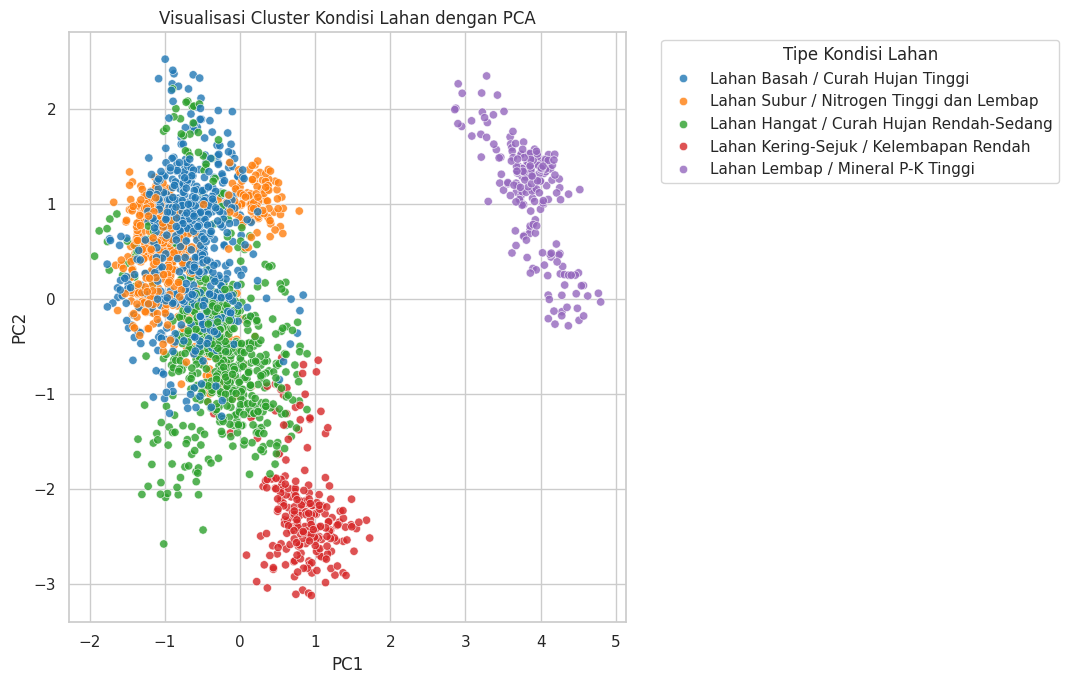

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_data[:, 0],
    "PC2": pca_data[:, 1],
    "label_tipe_lahan": clustered_df["label_tipe_lahan"],
})

plt.figure(figsize=(11, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label_tipe_lahan", palette="tab10", alpha=0.8)
plt.title("Visualisasi Cluster Kondisi Lahan dengan PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Tipe Kondisi Lahan", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Interpretasi hasil cell 14

Visualisasi PCA memperlihatkan sebaran cluster dalam 2 dimensi. Warna menunjukkan tipe kondisi lahan. Grafik ini membantu pembaca melihat bahwa data yang berdimensi 7 dapat divisualisasikan secara lebih sederhana.


## 15. Menyimpan Hasil Clustering

**Tujuan cell:** menyimpan dataset hasil clustering, ringkasan cluster, dan model K-Means.

**Penjelasan teknis:**

- `clustered_df.to_csv()` menyimpan dataset yang sudah memiliki kolom cluster dan label tipe lahan.
- `cluster_summary.to_csv()` menyimpan ringkasan profil cluster.
- `joblib.dump()` menyimpan model K-Means, scaler, daftar fitur, dan peta label cluster.

**Alasan:** file hasil clustering dapat diunduh dari Kaggle dan digunakan untuk laporan, lampiran, atau pengembangan aplikasi berikutnya.


In [30]:
clustered_data_path = "/kaggle/working/crop_recommendation_with_land_clusters.csv"
cluster_summary_path = "/kaggle/working/cluster_summary_labeled.csv"
model_path = "/kaggle/working/kmeans_land_clustering.pkl"

clustered_df.to_csv(clustered_data_path, index=False)
cluster_summary.to_csv(cluster_summary_path, index=False)

joblib.dump({
    "model": kmeans_model,
    "scaler": scaler,
    "feature_columns": feature_columns,
    "cluster_label_map": cluster_label_map,
}, model_path)

print("Dataset hasil clustering:", clustered_data_path)
print("Ringkasan cluster:", cluster_summary_path)
print("Model K-Means:", model_path)


Dataset hasil clustering: /kaggle/working/crop_recommendation_with_land_clusters.csv
Ringkasan cluster: /kaggle/working/cluster_summary_labeled.csv
Model K-Means: /kaggle/working/kmeans_land_clustering.pkl


### Interpretasi hasil cell 15

Output menunjukkan dataset hasil clustering, ringkasan cluster, dan model K-Means berhasil disimpan di folder `/kaggle/working/`. File-file tersebut dapat diunduh untuk lampiran atau digunakan kembali pada tahap pengembangan.


## 16. Ringkasan

Notebook ini menunjukkan bahwa K-Means dapat digunakan untuk melakukan segmentasi kondisi lahan berdasarkan fitur tanah dan lingkungan. Jumlah cluster ditentukan menggunakan Elbow Method dan menghasilkan 5 tipe kondisi lahan. Hasil clustering ini digunakan pada bagian Results dan Discussion laporan project.
